# Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval<br>every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>reporting | Objective | Prunning | MOO | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | |100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models | Running more epochs to get a better model |
|2 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose/Strict | All models | Saw overfitting, but didn't have the metric values |
|3 | |200 | 10,000 | 200 | `eval > 3` | Structural | Yes | None | Last  | Recall |Yes|No| Loose/Strict | - Full graph <br> - Dominant sets | Noticed that by running all 10,000 epocs had lower recall|
|4 | |200 | 4,000 | 50 | `eval > 3` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph  | Added early stoppage and best recall reporting to get better models |
|5 | |200 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph | We should include all reviews, not only the good ones<br>Light GCN is only about interactions. |
|6 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Since last model worked better for Full graph, running for all |
|7 |  |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Trained the random sets based on the best parameters for each the dominant set |
|8 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective |  Objective | Prunning | MOO  | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | | 100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Using iterations from 100K, results seem more consistent |
|2 |  | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models |Trained the random sets based on the best parameters <br>for each the dominant set as in the 100K |
|2 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |
 

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances, plot_pareto_front
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

#exp_name = 'e_100K'
#exp_name = 'e_gowalla'
exp_name = 'e_yelp'
#version=f'historic_results/{exp_name}/pass_0/'
#version=f'historic_results/sandbox/'
version=''

/home/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_yelp_1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,23850.626037,149.556322,4.209479,31169,37130,421521,143637,143637,50,True,ndcg,1,128,0.000718,0.000005,2220,Adam,"[0.685271143913269, 0.6813642382621765, 0.6762...","[0.6380205154418945, 0.636982262134552, 0.6350...","[0.00045437970668891223, 0.0004899922423014478...","[0.00010578501957812305, 0.0001121005431350258...","[0.00022434714882953896, 0.0002427128562117657...",0.033112,0.007088,0.019457,2750,True,1839.0,1040.0,5568.688786
8,e_yelp_1c1dcs_rand1,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,25030.203555,178.895828,3.811466,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000871,0.000008,3224,RMSprop,"[0.672247052192688, 0.6580796241760254, 0.6473...","[0.6377094984054565, 0.63155597448349, 0.62429...","[0.0004990950017990069, 0.000706890101557589, ...","[0.0001199949475811545, 0.0001515725653656688,...","[0.0003065244358066444, 0.00043754361897931565...",0.035135,0.007279,0.020229,3750,False,NaN,NaN,NaN
1,e_yelp_1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,12690.195186,24.427589,3.460158,1838,1040,34724,143637,143637,50,True,ndcg,1,96,0.007823,0.000004,1576,Adam,"[0.6853654980659485, 0.022437838837504387, 0.0...","[0.6512641906738281, 0.6059452295303345, 0.595...","[0.000508437637630596, 0.004058912297900497, 0...","[0.00011210054313502591, 0.0015694076038903625...","[0.00024754385909292947, 0.0027627395273753645...",0.004059,0.001569,0.002763,50,True,1839.0,1040.0,5568.688786
2,e_yelp_1c1dcs_strict_rand1,0.579769,0.003664,0.000971,0.002405,0.580122,0.003738,0.000985,0.002340,24534.075670,74.836760,3.669077,18147,17658,34724,143637,143637,50,True,ndcg,4,128,0.001434,0.000091,548,RMSprop,"[0.593552827835083, 0.40243589878082275, 0.289...","[0.6718589067459106, 0.6652122139930725, 0.659...","[0.0007133720158410252, 0.001771100624811853, ...","[0.00014525704180876593, 0.0004310344827586207...","[0.00037828831445888385, 0.0010562713901707882...",0.003825,0.000979,0.002459,1100,True,NaN,NaN,NaN
3,e_yelp_1c1dcs_strict_rand2,0.627104,0.004255,0.000955,0.002700,0.627112,0.004297,0.000980,0.002813,17588.948452,79.872607,3.749703,18147,17658,34724,143637,143637,50,True,ndcg,3,32,0.001270,0.000002,806,RMSprop,"[0.663737416267395, 0.6034893989562988, 0.5501...","[0.6857894659042358, 0.6836318969726562, 0.681...","[0.00047163545068136184, 0.0012781265553664857...","[0.0001042061386888973, 0.00028419856006062905...","[0.00027965424611190007, 0.0008177184771914951...",0.004316,0.000963,0.002737,1450,True,NaN,NaN,NaN


## Losses for "Strict" DS Runs

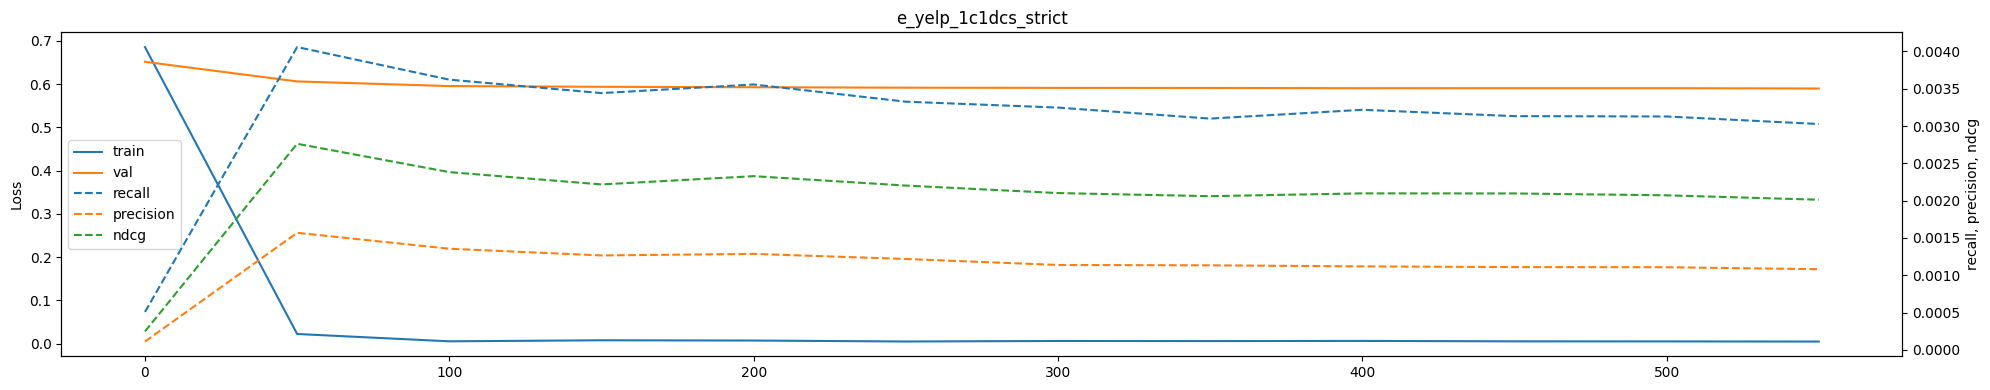

In [26]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

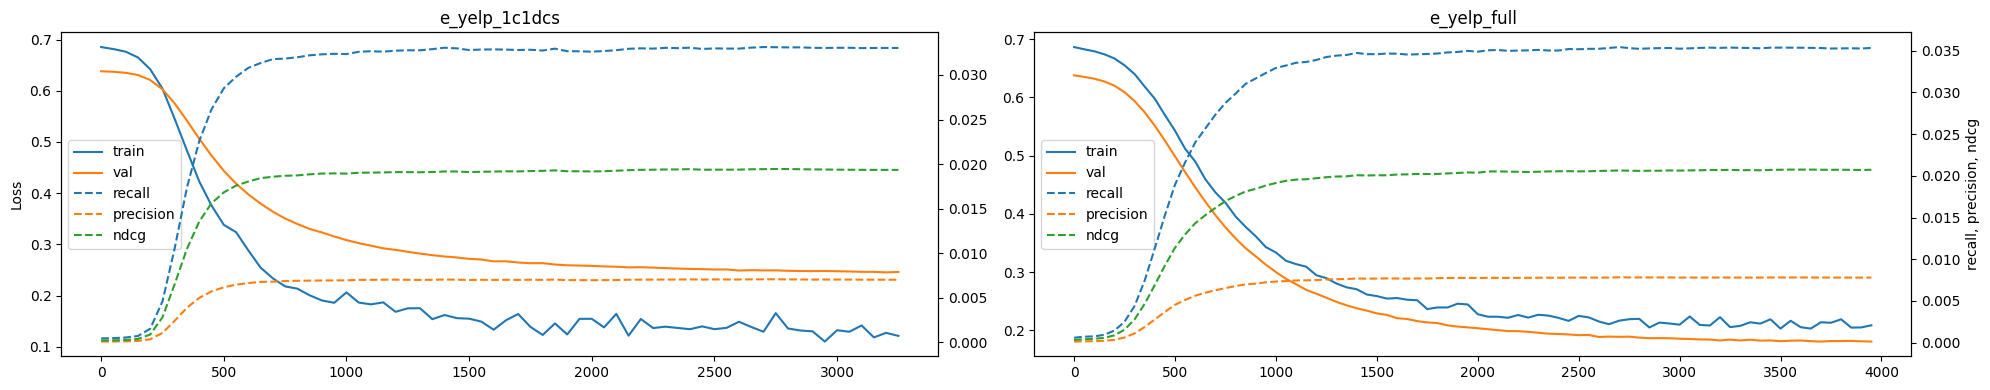

In [27]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Random runs losses for non-strict runs

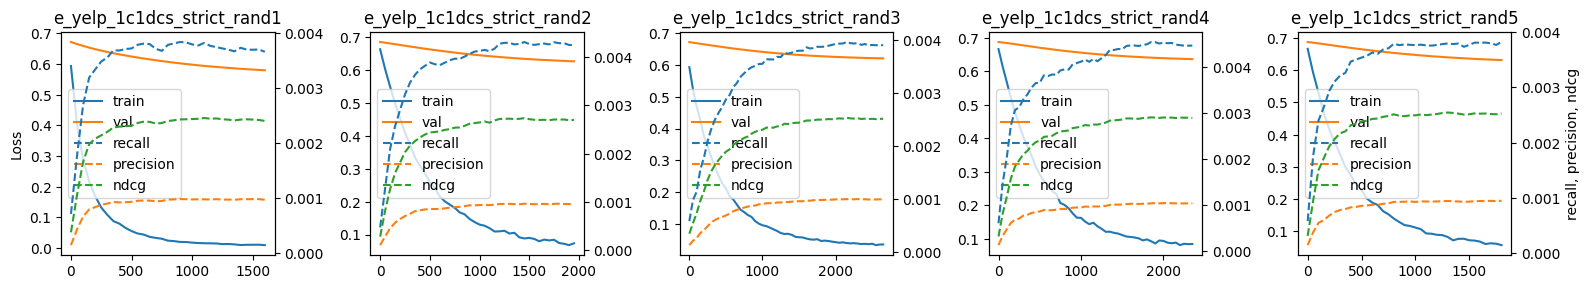

In [28]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict_rand.png')
plt.show()

## Random runs losses for non-strict runs

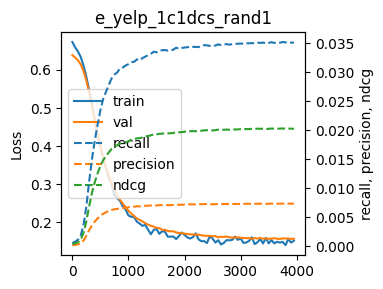

In [29]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose_rand.png')
plt.show()

## Trial analysis

In [21]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

objective_metric = df['objective_metric'].unique()[0]
objective_metric = objective_metric if objective_metric is not None else 'recall'
objective_metric_dict = {'recall':0, 'precision':1, 'ndcg':2}

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study, target=lambda t: t.values[objective_metric_dict[objective_metric]]) #added target for multi-objective
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,optimizer,lr,batch_size,n_layers,lambda_val,embedding_dim
e_gowalla_1c1dcs,0.841517,0.090666,0.031863,0.020644,0.008505,0.006805
e_gowalla_1c1dcs_strict,0.493159,0.021187,0.022429,0.387912,0.056460,0.018854
e_gowalla_1c2dcs,0.859334,0.027475,0.017350,0.033016,0.054826,0.007999
e_gowalla_1c2dcs_strict,0.628077,0.029148,0.019779,0.267197,0.046106,0.009693
e_gowalla_1c3dcs,0.690653,0.102755,0.022146,0.138673,0.035918,0.009854
e_gowalla_1c3dcs_strict,0.755715,0.021386,0.023782,0.152092,0.025862,0.021163
e_gowalla_full,0.768949,0.038951,0.043709,0.013277,0.051433,0.083681


In [22]:
studies = optuna.get_all_study_names(storage=f'sqlite:///{version}{exp_name}.sqlite3')

results = {}
for study_name in studies:
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')
    is_multi = len(study.directions) > 1

    trials = {}
    for trial in study.get_trials():
        parameters = trial.params
        parameters.update({'status': trial.state})
        parameters.update({'value': trial.values if is_multi else trial.value})
        parameters.update({'multi_objective':is_multi})
        trials[trial.number] = parameters

    results[study_name] = trials

flattened_data = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in results.items() 
    for inner_key, values in inner_dict.items()
}
flattened_data

trials_params = pd.DataFrame.from_dict(flattened_data, orient='index').reset_index(names=['study','trial'])
trials_params['status'] = trials_params['status'].map({x: str(TrialState(x)).split('.')[1].lower() for x in range(0,5)})
trials_params.head()


,study,trial,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,status,value,multi_objective
0,Study_e_gowalla_full,0,4,128,0.005321,0.074500,1726,SGD,complete,"[0.0005892972021959314, 7.870587447250318e-05,...",True
1,Study_e_gowalla_full,1,2,32,0.021147,0.006952,3385,Adam,complete,"[0.0210416252757553, 0.0024298345502043006, 0....",True
2,Study_e_gowalla_full,2,1,128,0.000327,0.025607,3410,Adam,complete,"[0.00047083401312285957, 7.870587447250318e-05...",True
3,Study_e_gowalla_full,3,2,32,0.056051,0.000609,1575,Adam,complete,"[0.026821930099092867, 0.0032554089356286423, ...",True
4,Study_e_gowalla_full,4,4,96,0.006109,0.000001,1276,RMSprop,complete,"[0.04138926189250355, 0.004769241074418917, 0....",True


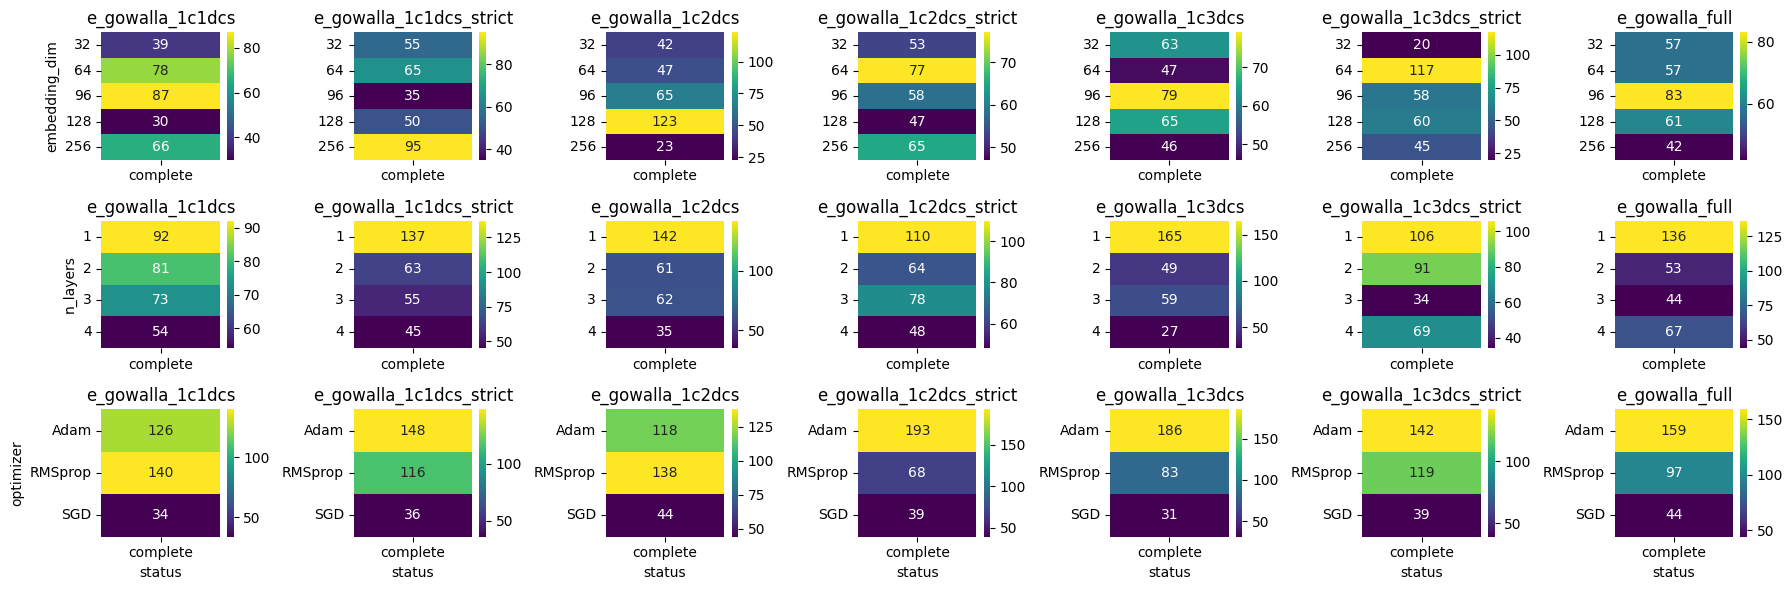

In [23]:
plt.figure(figsize=(18,6))
hyper_params = ['embedding_dim','n_layers','optimizer']

for j,param in enumerate(hyper_params):
    df_t = trials_params.groupby(['study','status',param]).count().reset_index()
    df_t = df_t[~df_t['study'].str.contains('_rand')]

    for i, study in enumerate(df_t['study'].unique()):
        plt.subplot(len(hyper_params),df_t['study'].nunique(),j*(df_t['study'].nunique())+i+1)
        plt.title(study[len('Study_'):])
        sub_df = df_t[df_t['study']==study]
        ax = sns.heatmap(sub_df.pivot(index=param, columns='status', values='trial'), cmap='viridis', annot=True, fmt='.0f')
        plt.yticks(rotation=0)

        if i != 0:
            ax.set(ylabel=None)
        
        if j != len(hyper_params)-1:
            ax.set(xlabel=None)

plt.tight_layout()
plt.savefig(version+'trials_hyperparmeters.png')
plt.show()

In [24]:
study_name = f'Study_{exp_name}_full'

if trials_params['multi_objective'].unique()[0]:
    print('Plotting pareto front ...')
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')

    best_trials = study.best_trials
    for trial in best_trials:
        print(f"Trial #{trial.number}: Values={trial.values}, Params={trial.params}")

    fig = plot_pareto_front(study, target_names=["Recall", "Precision","NDCG"])
    fig.update_layout(title=f"3D Pareto Front: {study_name}", width=800, height=800)
    fig.show()
else:
    print('Not a multi-objective run ... ')


Plotting pareto front ...
Trial #222: Values=[0.11419535803413876, 0.014106772054390785, 0.06460874798892755], Params={'n_layers': 1, 'embedding_dim': 256, 'lr': 0.0009463388507176841, 'lambda_val': 2.8807178813664366e-05, 'batch_size': 2234, 'optimizer': 'RMSprop'}


In [25]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}

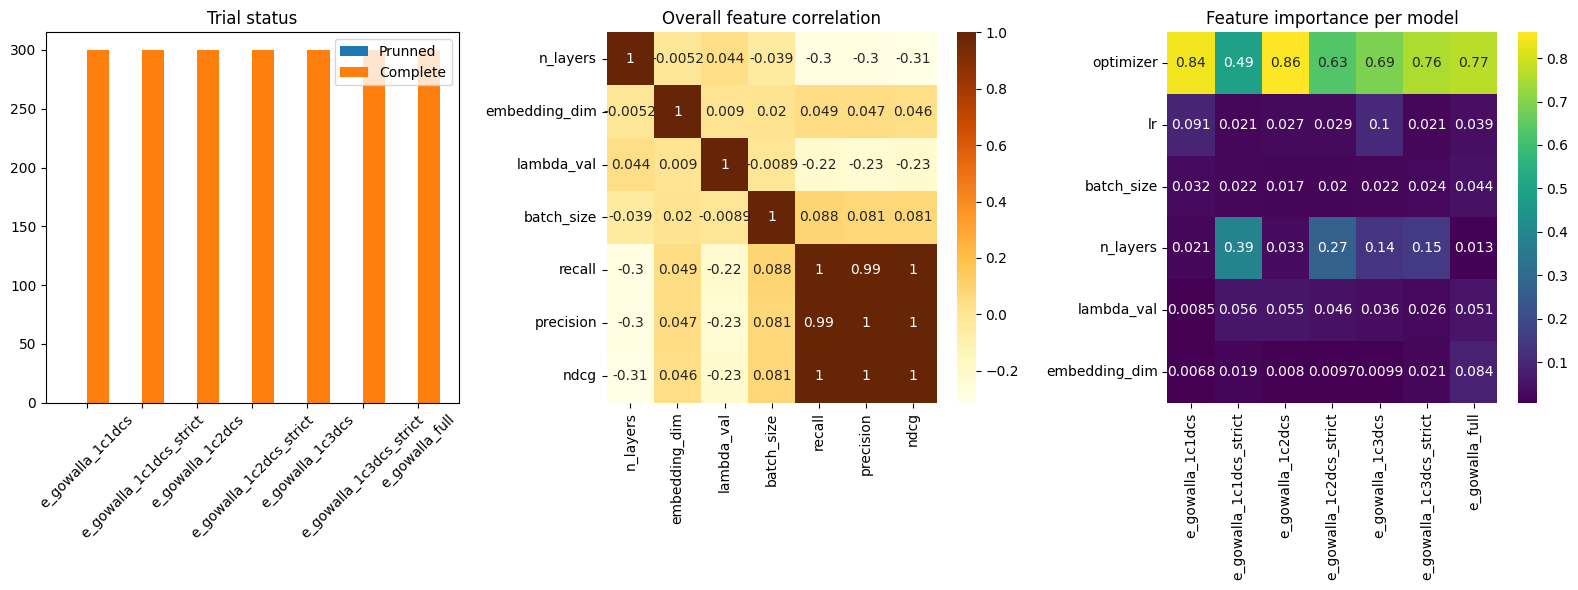

In [26]:
x = np.arange(len(trials_df))
width = 0.4

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index, rotation=45)

plt.title('Trial status')

plt.subplot(1,3,2)
if trials_params['multi_objective'].unique()[0]:
    sns.heatmap(trials_params.assign(recall=trials_params['value'].apply(pd.Series)[0], precision=trials_params['value'].apply(pd.Series)[1], ndcg=trials_params['value'].apply(pd.Series)[2])[['n_layers','embedding_dim','lambda_val','batch_size','recall','precision','ndcg']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')
else:
    sns.heatmap(trials_params[['n_layers','embedding_dim','lambda_val','batch_size','value']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')

plt.subplot(1,3,3)
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')

plt.tight_layout()
plt.savefig(version+'trials_feature_importance.png')
plt.show()

## Visualizations

In [30]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
7,1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,0.033112,2750,True,23850.626037,149.556322,4.209479,5568.688786,421521,1839.0,1040.0,1,128,0.000718,0.000005,2220,Adam
8,1c1dcs_rand,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,0.035135,3750,False,25030.203555,178.895828,3.811466,NaN,421521,NaN,NaN,1,128,0.000871,0.000008,3224,RMSprop
1,1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,0.004059,50,True,12690.195186,24.427589,3.460158,5568.688786,34724,1839.0,1040.0,1,96,0.007823,0.000004,1576,Adam
2,1c1dcs_strict_rand,0.579769,0.003664,0.000971,0.002405,0.580122,0.003738,0.000985,0.002340,0.003825,1100,True,24534.075670,74.836760,3.669077,NaN,34724,NaN,NaN,4,128,0.001434,0.000091,548,RMSprop
3,1c1dcs_strict_rand,0.627104,0.004255,0.000955,0.002700,0.627112,0.004297,0.000980,0.002813,0.004316,1450,True,17588.948452,79.872607,3.749703,NaN,34724,NaN,NaN,3,32,0.001270,0.000002,806,RMSprop


In [31]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  2 days, 10:53:53.036940


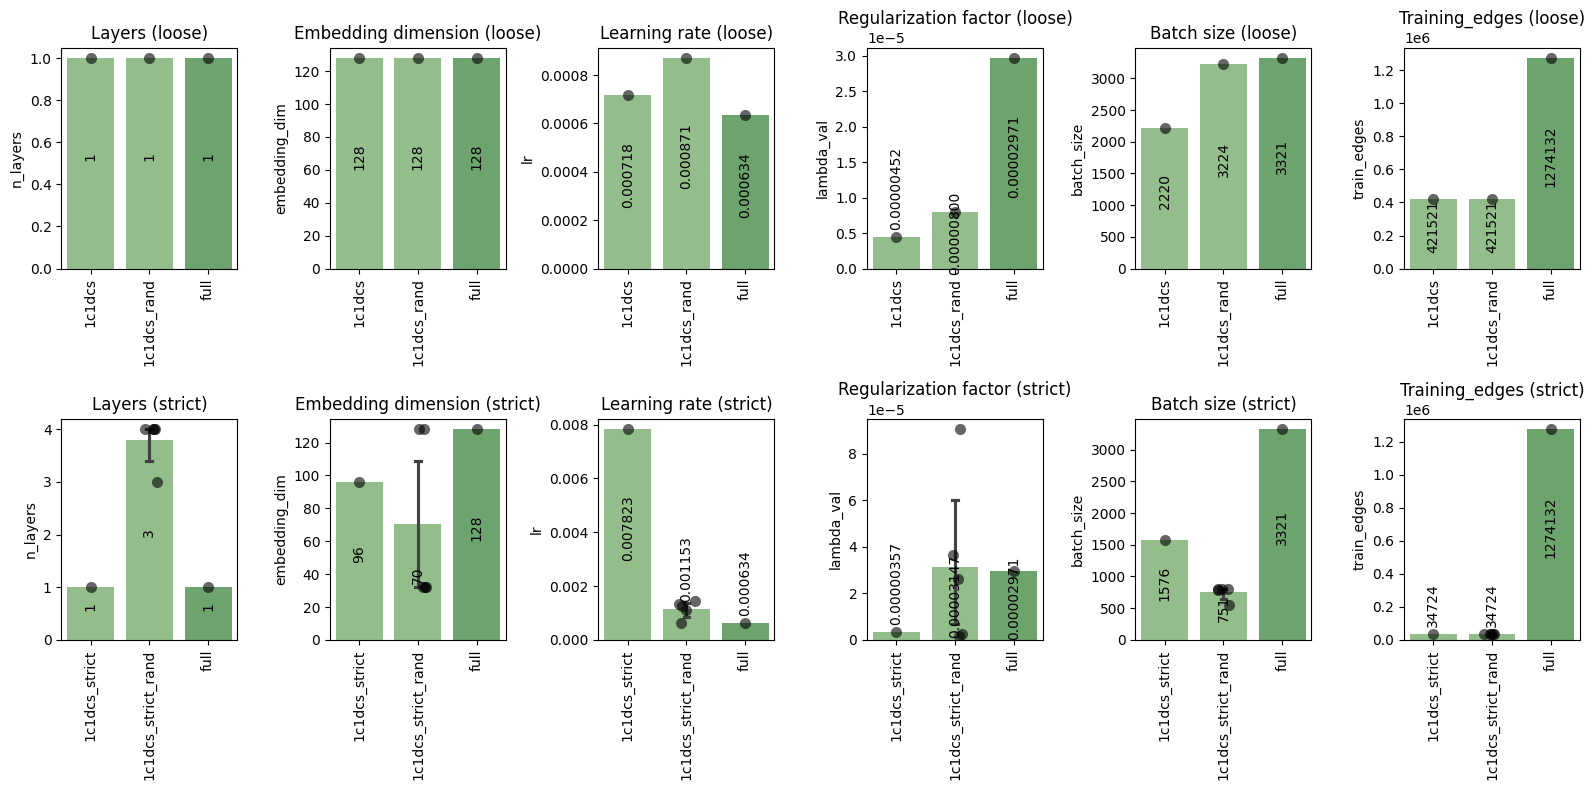

In [32]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,strict in enumerate([False, True]):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)


plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()

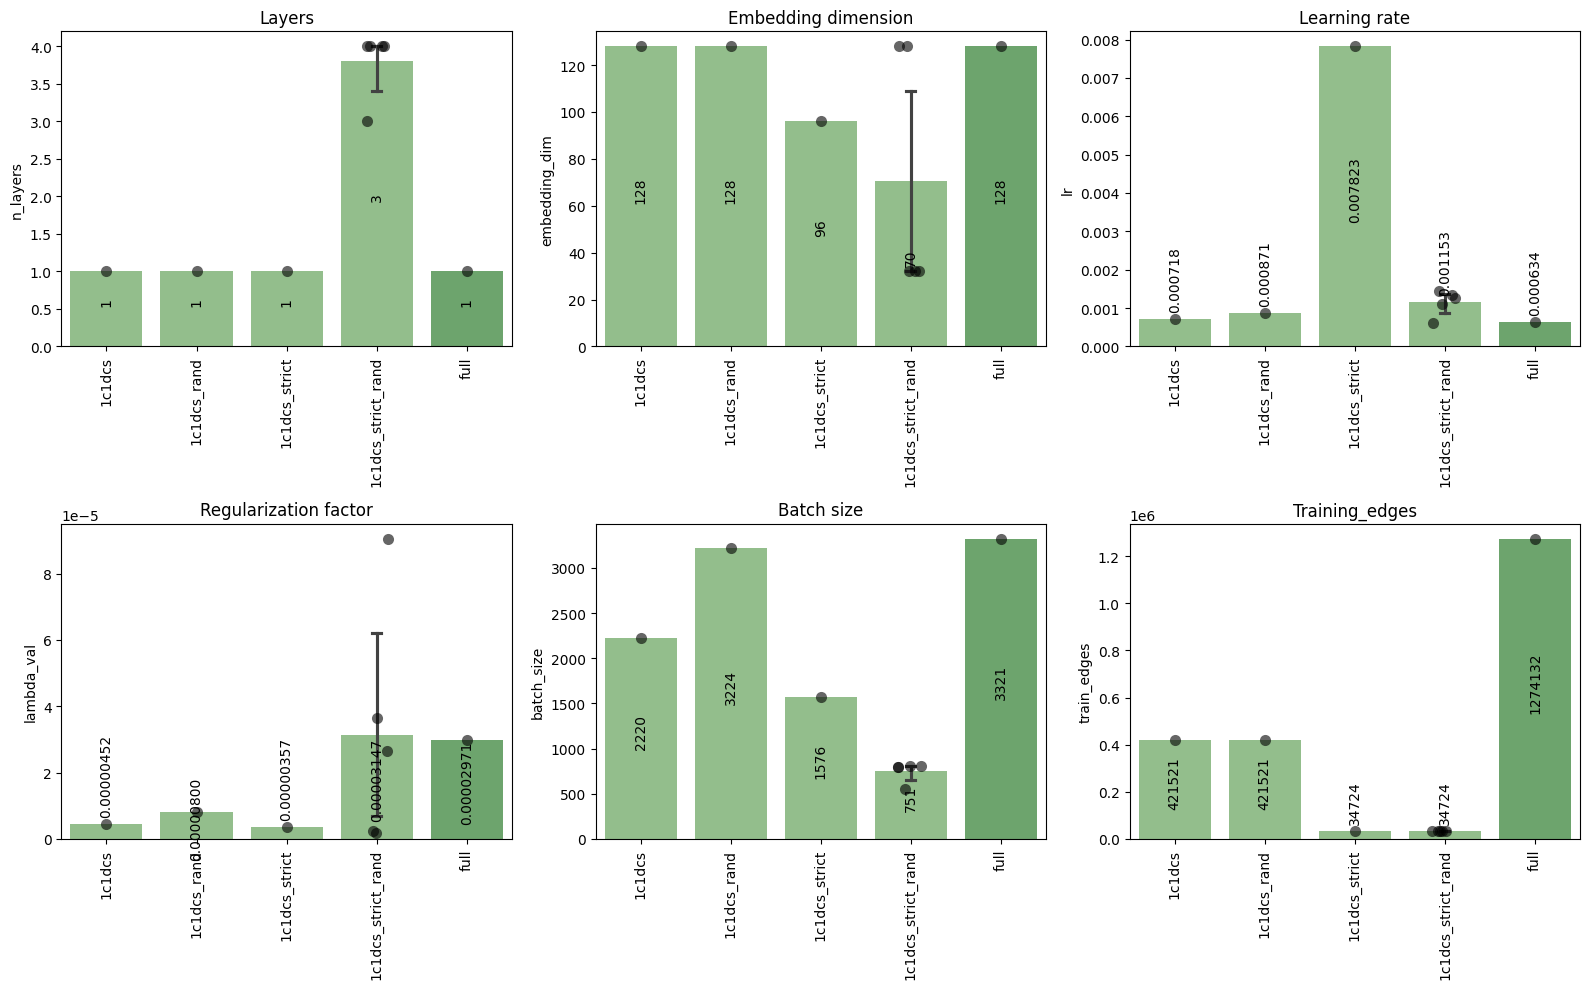

In [33]:

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])

plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

plt.figure(figsize=(16,10))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(n_plots_height,n_plots_wide,i+1)

    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()


In [34]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.245596,0.000000,0.033029,0.000000,0.007042,0.000000,0.019354,0.000000,0.246591,0.00000,0.032493,0.000000,0.006990,0.000000,0.019204,0.000000,0.033112,0.000000,2750.0,0.000000,1.0,0.0,23850.626037,0.000000,149.556322,0.000000,4.209479,0.000000,5568.688786,0.0,421521.0,1839.0,1040.0,[1],[128],[0.0007183006551542105],[4.521426485432383e-06],[2220],[Adam]
1,1c1dcs_rand,0.155710,0.000000,0.035024,0.000000,0.007263,0.000000,0.020181,0.000000,0.155569,0.00000,0.034115,0.000000,0.007168,0.000000,0.019882,0.000000,0.035135,0.000000,3750.0,0.000000,0.0,0.0,25030.203555,0.000000,178.895828,0.000000,3.811466,0.000000,0.000000,0.0,421521.0,0.0,0.0,[1],[128],[0.000870520171613823],[8.004253683939247e-06],[3224],[RMSprop]
2,1c1dcs_strict,0.590177,0.000000,0.003028,0.000000,0.001082,0.000000,0.002013,0.000000,0.590092,0.00000,0.002811,0.000000,0.001129,0.000000,0.001920,0.000000,0.004059,0.000000,50.0,0.000000,1.0,0.0,12690.195186,0.000000,24.427589,0.000000,3.460158,0.000000,5568.688786,0.0,34724.0,1839.0,1040.0,[1],[96],[0.007822927276622295],[3.567347607875195e-06],[1576],[Adam]
3,1c1dcs_strict_rand,0.619042,0.022745,0.004024,0.000332,0.000980,0.000033,0.002609,0.000193,0.619216,0.02266,0.004048,0.000283,0.000973,0.000028,0.002580,0.000222,0.004090,0.000331,1570.0,425.147033,1.0,0.0,21959.133450,3568.777336,88.991729,20.213503,3.653176,0.102005,0.000000,0.0,34724.0,0.0,0.0,"[4, 3]","[128, 32]","[0.0014337059824812508, 0.0012702568149946026,...","[9.050147705306549e-05, 2.3768863399722796e-06...","[548, 806, 810, 793, 801]",[RMSprop]
4,full,0.181320,0.000000,0.035378,0.000000,0.007815,0.000000,0.020749,0.000000,0.181129,0.00000,0.036201,0.000000,0.008079,0.000000,0.021404,0.000000,0.035349,0.000000,3650.0,0.000000,0.0,0.0,28505.983299,0.000000,191.140232,0.000000,4.258439,0.000000,0.000000,0.0,1274132.0,0.0,0.0,[1],[128],[0.0006340132793158045],[2.970506579255523e-05],[3321],[RMSprop]


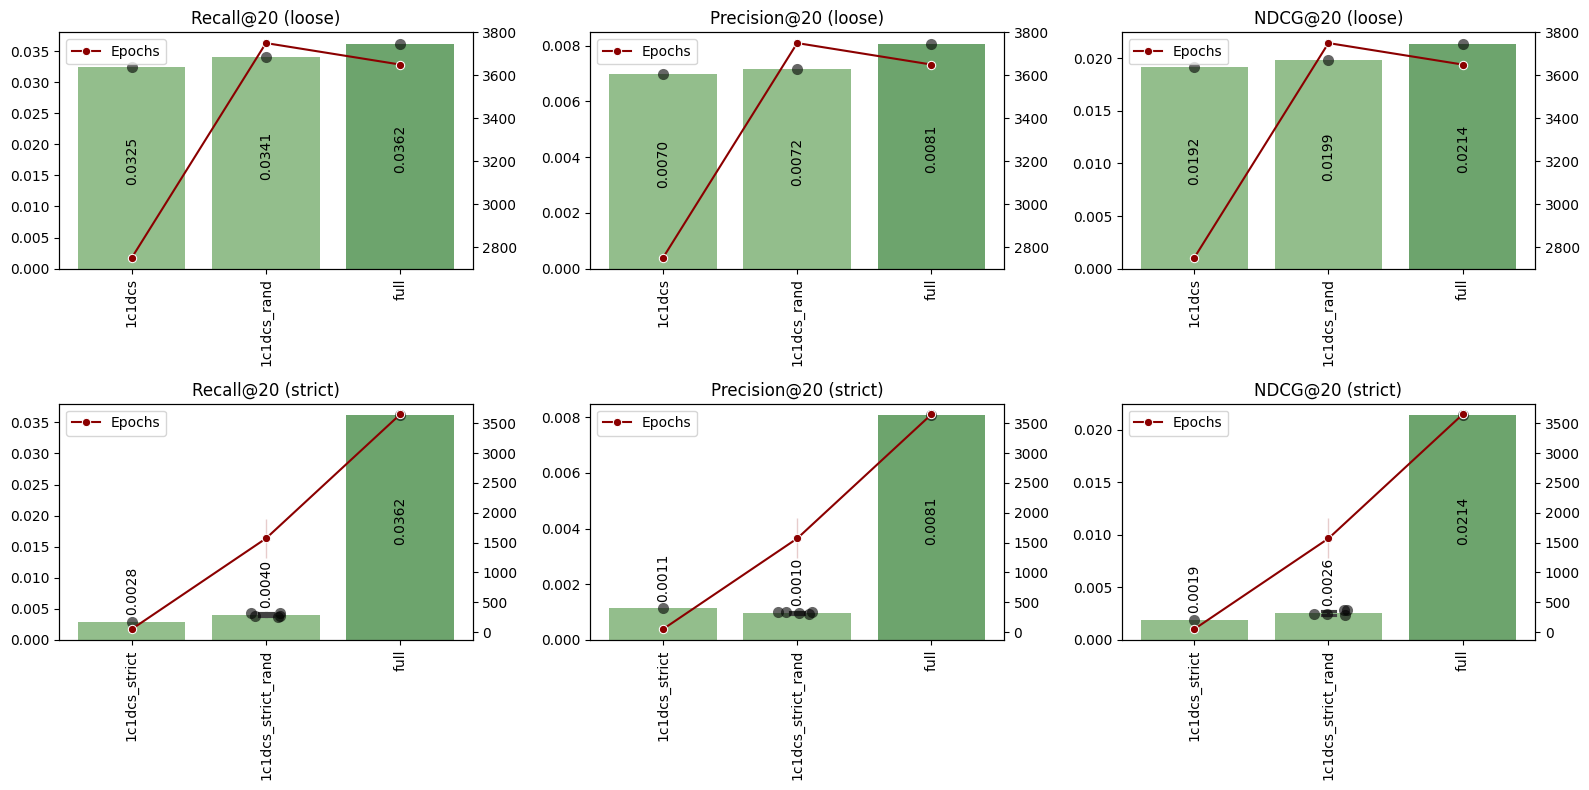

In [35]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

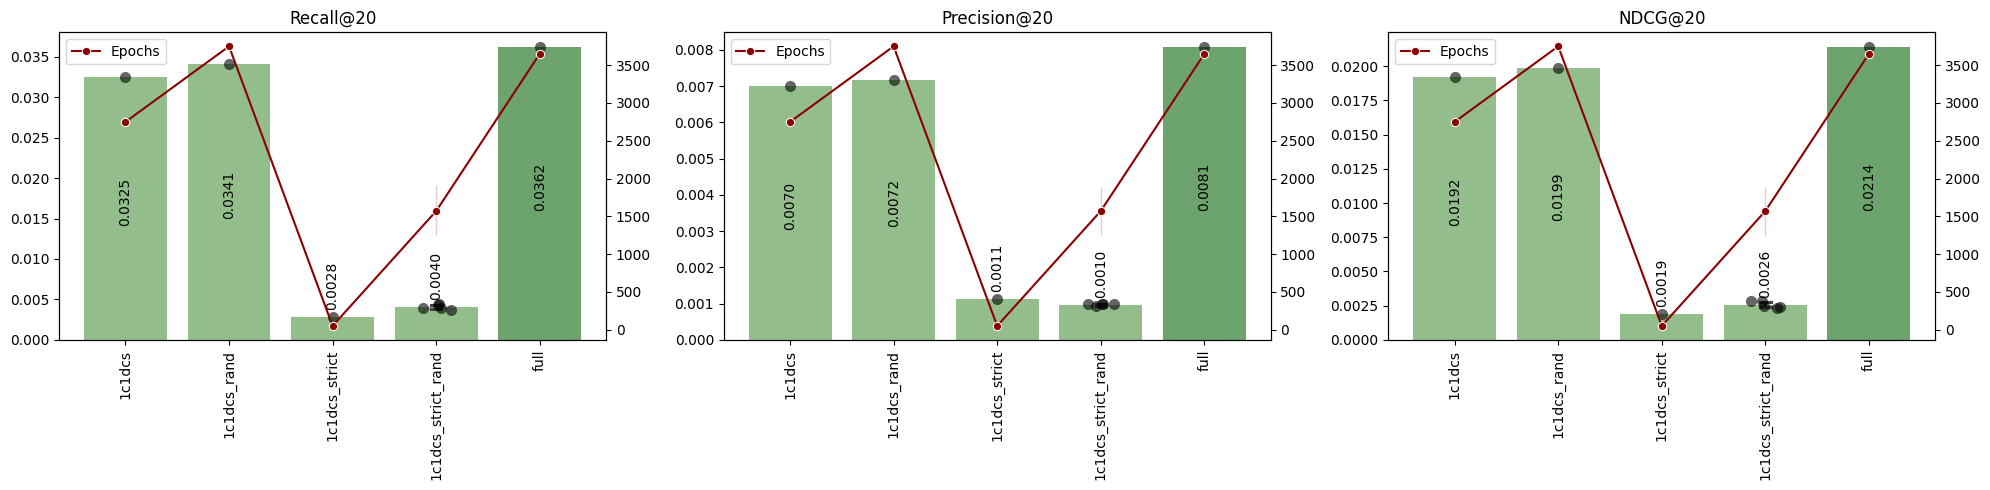

In [36]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

plt.figure(figsize=(20,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)
    
    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)

    ax2 = ax.twinx()
    #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
    if 'cycle' in random_experiments_stats.columns:
        sns.lineplot(data=random_experiments_stats, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
        ax2.set_ylabel('Training epochs')

    plt.title(titles[i])
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_metrics.png')
plt.show()

<Figure size 1600x1000 with 0 Axes>

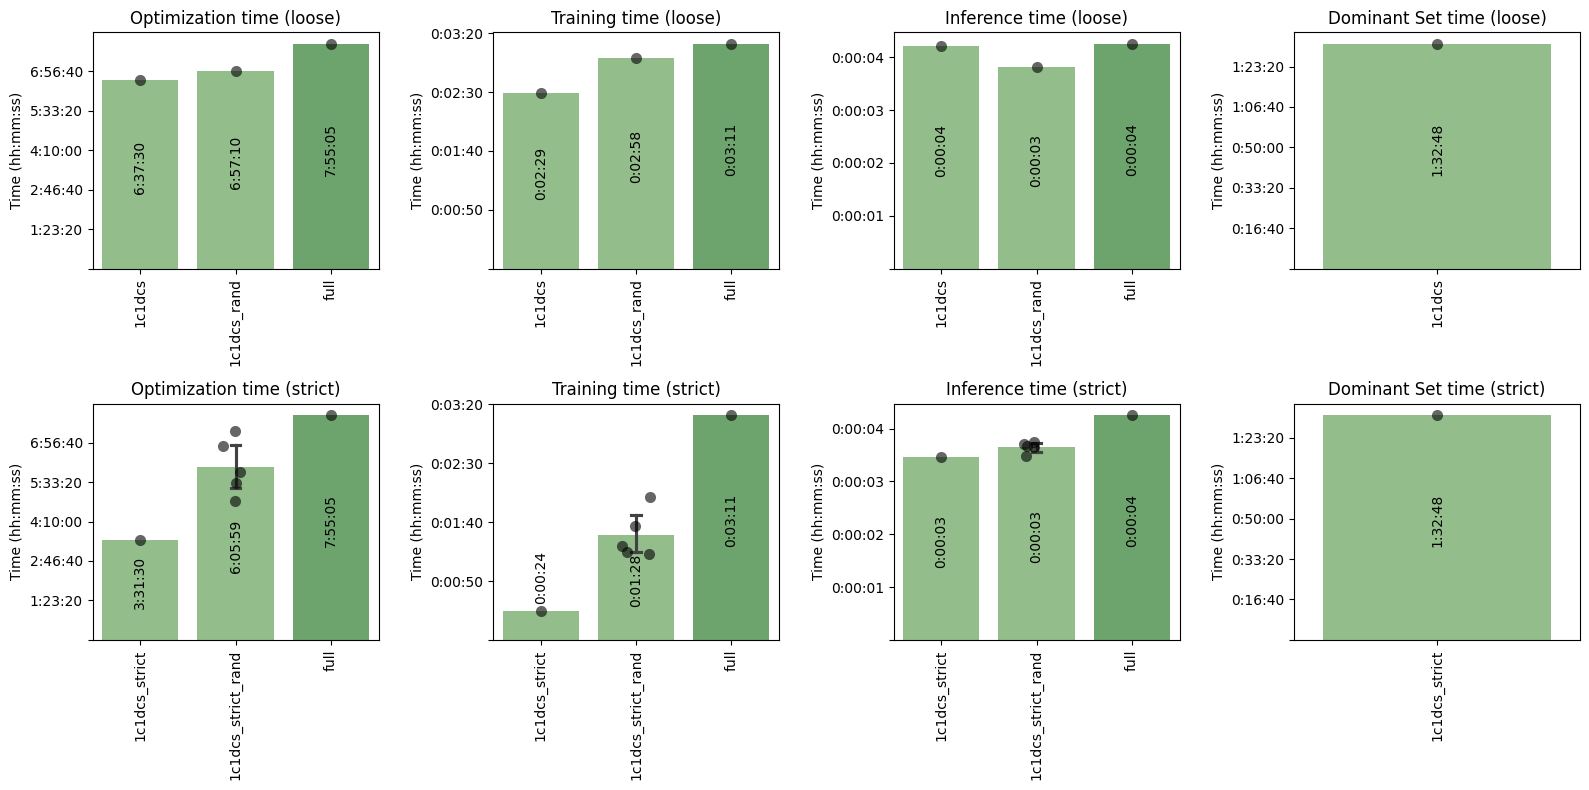

In [37]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]

        # Create the barplot
        ax = sns.barplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            errorbar=('ci', 95),
            capsize=0.1, 
            alpha=0.7, 
            palette=color_dict,  
            hue='experiment', 
            legend=False
        ) 

        # --- FIX FOR BAR LABELS ---
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        # --------------------------


        # Add the stripplot
        sns.stripplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            color='black', 
            size=8, 
            alpha=0.6, 
            jitter=0.15,
            ax=ax
        )
        
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

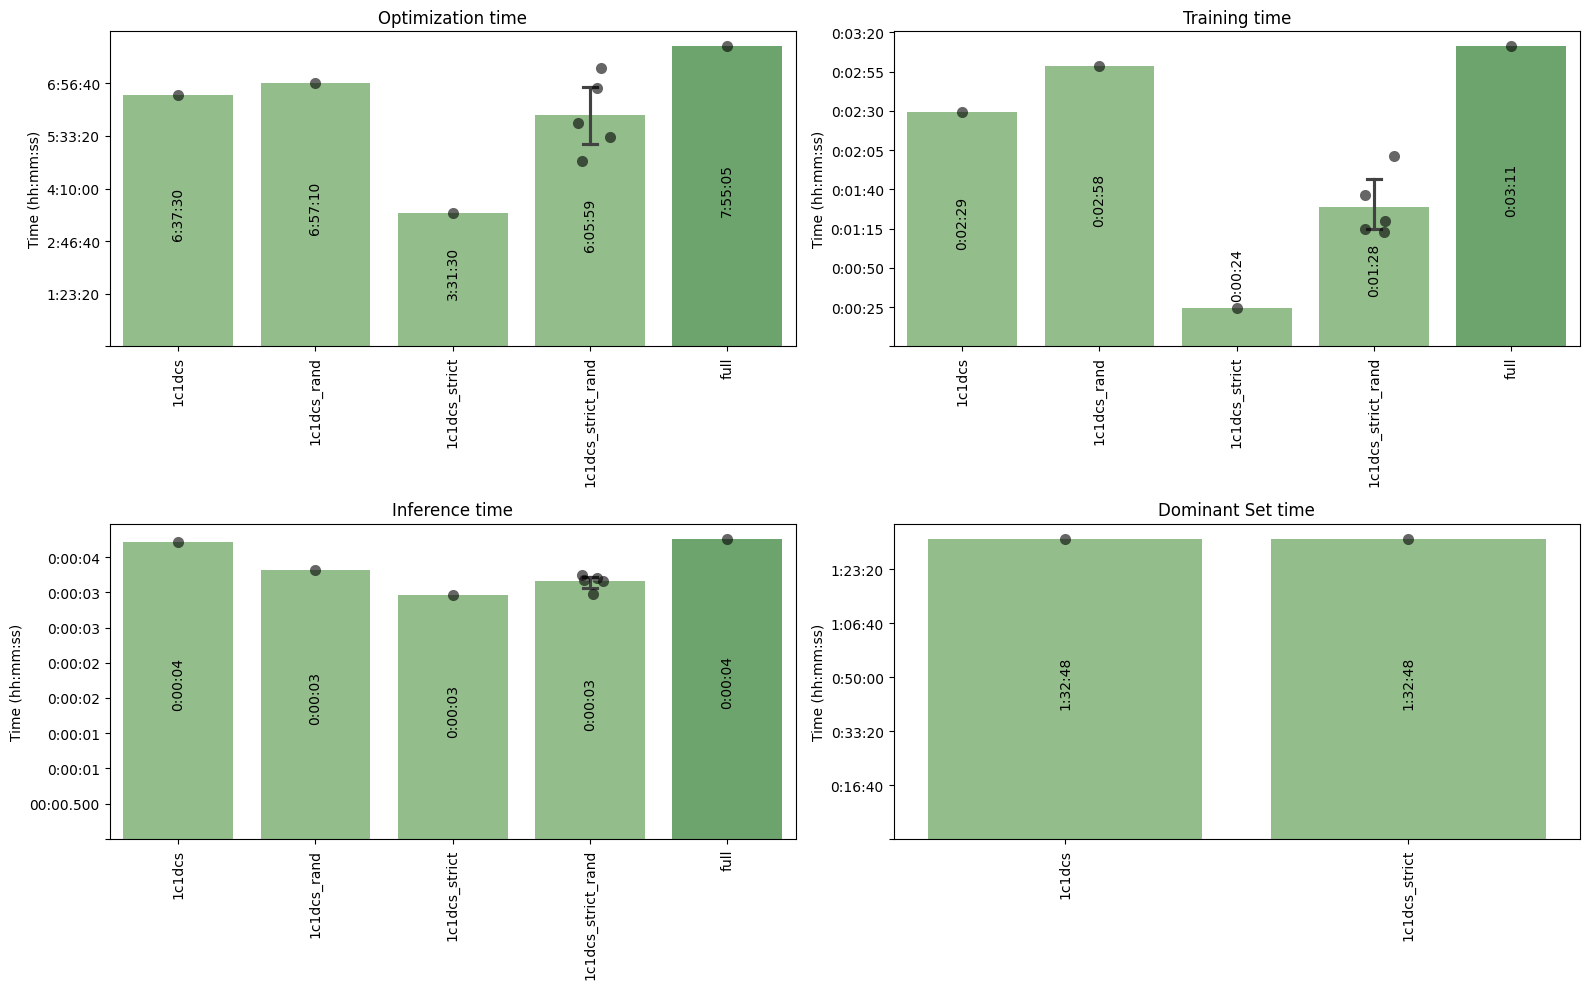

In [38]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i, metric in enumerate(plots):
    plt.subplot(n_plots_height, n_plots_wide, i+1)

    # Create the barplot
    ax = sns.barplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        errorbar=('ci', 95),
        capsize=0.1, 
        alpha=0.7, 
        palette=color_dict,  
        hue='experiment', 
        legend=False
    ) 

    # --- FIX FOR BAR LABELS ---
    # Iterate through all containers generated by Seaborn's hue
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        # Generate a label list directly from the bar heights in this specific container
        labels = [format_time(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    # --------------------------


    # Add the stripplot
    sns.stripplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        color='black', 
        size=8, 
        alpha=0.6, 
        jitter=0.15,
        ax=ax
    )
    
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

    # Use the mean of the actual current metric to decide the axis label
    current_mean = random_experiments_stats[metric].mean()
    if current_mean < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
#plt.savefig(version+'experiments_times.png')
plt.show()

In [39]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [40]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.2456,0.0330,0.0070,0.0194,0.2466,0.0325,0.0070,0.0192,0.0331,"2,750.0000",1.0000,421521.0,1839.0,1040.0,06:37:30,00:02:29,00:00:04,01:32:48,[1],[128],[0.0007183006551542105],[4.521426485432383e-06],[2220],[Adam]
1,1c1dcs_rand,0.1557,0.0350,0.0073,0.0202,0.1556,0.0341,0.0072,0.0199,0.0351,"3,750.0000",0.0000,421521.0,0.0,0.0,06:57:10,00:02:58,00:00:03,00:00:00,[1],[128],[0.000870520171613823],[8.004253683939247e-06],[3224],[RMSprop]
2,1c1dcs_strict,0.5902,0.0030,0.0011,0.0020,0.5901,0.0028,0.0011,0.0019,0.0041,50.0000,1.0000,34724.0,1839.0,1040.0,03:31:30,00:00:24,00:00:03,01:32:48,[1],[96],[0.007822927276622295],[3.567347607875195e-06],[1576],[Adam]
3,1c1dcs_strict_rand,0.6190 ± 0.0227,0.0040 ± 0.0003,0.0010 ± 0.0000,0.0026 ± 0.0002,0.6192 ± 0.0227,0.0040 ± 0.0003,0.0010 ± 0.0000,0.0026 ± 0.0002,0.0041 ± 0.0003,"1,570.0000 ± 425.1470",1.0000,34724.0,0.0,0.0,06:05:59 ± 00:59:28,00:01:28 ± 00:00:20,00:00:03 ± 00:00:00,00:00:00,"[4, 3]","[128, 32]","[0.0014337059824812508, 0.0012702568149946026,...","[9.050147705306549e-05, 2.3768863399722796e-06...","[548, 806, 810, 793, 801]",[RMSprop]
4,full,0.1813,0.0354,0.0078,0.0207,0.1811,0.0362,0.0081,0.0214,0.0353,"3,650.0000",0.0000,1274132.0,0.0,0.0,07:55:05,00:03:11,00:00:04,00:00:00,[1],[128],[0.0006340132793158045],[2.970506579255523e-05],[3321],[RMSprop]


# Conclusions and actions

## Symptoms
- Model is overfitting, given the train vs. val losses tracking (don't know about the performance metrics, since they haven't been captured.)
- Full graph is converging too fast, but train/val curves are  too far apart, system may have learned "too" quickly

## Suggested actions
- Add tracking for Recall, precision and NDCG (already did after current run.)
- Verify the random sample methods, since it only randomizes using train_test_split from sklearn, but sets may not be fully-connected or even coherent -> Rolando said this before.
    - Nos llevamos aristas siempre que embos nodos esten representados.
- After the right random sample calculate the dominant set from the sample set. --> from here sample random or structure preserving random.
    - The 5 random runs (absolute random), should sample from the random sample ONLY and maybe use a similar algorithm as the full random sample method, 
        - or maybe sample from the main sample with some other variation, limiting the total amount of rows
- Reduce the seach space for certain parameters (embedding_dim, remove the 32 option for instance, layers remove the 4 layers options) --> **Run 300 instances.**
    - Had done this before, but because of th randomization, we may have gotten a bad batch and seems to not converge.




In [ ]:
#import optuna

# Delete an entire study from the SQLite file
#optuna.delete_study(
#    study_name="Study_e_yelp_1c1dcs_rand3", 
#    storage="sqlite:///e_yelp.sqlite3"
#)


/home/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_name = 'e_yelp'
version=f'historic_results/{exp_name}/pass_0/runs/'
#version=f'historic_results/sandbox/'
#version=''

df = pd.read_parquet(f'{version}{exp_name}_second.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_yelp_1c1dcs_rand3,0.178155,0.032737,0.006729,0.018673,0.177844,0.032747,0.006878,0.019018,25015.123947,113.307534,3.893086,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.002015,0.000043,1780,Adam,"[0.6876915097236633, 0.6856294870376587, 0.682...","[0.6789335608482361, 0.677962064743042, 0.6764...","[0.0004840103725697058, 0.0005067946272088255,...","[0.0001215738284703802, 0.00012788935202728306...","[0.0002848037245754263, 0.00029033227213868797...",0.032905,0.006764,0.018743,2200,True,NaN,NaN,NaN
1,e_yelp_1c1dcs_rand4,0.175466,0.033701,0.006873,0.019038,0.176662,0.033611,0.007075,0.019159,23008.174562,149.230824,3.836971,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001561,0.000012,2263,RMSprop,"[0.687966525554657, 0.679949939250946, 0.66589...","[0.678741455078125, 0.6735095977783203, 0.6615...","[0.0007406135010890442, 0.0011390320386249749,...","[0.00014209928003031455, 0.0002431476569407604...","[0.00037494897855529496, 0.0006932431696198659...",0.033712,0.006879,0.019059,3150,True,NaN,NaN,NaN
2,e_yelp_1c1dcs_rand5,0.193885,0.033154,0.006860,0.018863,0.194443,0.033564,0.007059,0.019521,22266.499219,147.418636,3.827301,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001540,0.000024,2177,Adam,"[0.6881386041641235, 0.6862046718597412, 0.684...","[0.6789470911026001, 0.678222119808197, 0.6772...","[0.0005218014309207881, 0.0005576408172357987,...","[0.00011841606669192878, 0.0001247315902488316...","[0.00028794988592521466, 0.0003136457203972603...",0.033381,0.006878,0.018935,3100,True,NaN,NaN,NaN
9,e_yelp_1c2dcs,0.262379,0.035055,0.007455,0.020135,0.262978,0.035181,0.007677,0.020476,27129.864139,84.055824,3.629803,31604,37885,575241,143637,143637,50,True,ndcg,1,96,0.000540,0.000096,3010,RMSprop,"[0.6877479553222656, 0.6801468133926392, 0.668...","[0.6514043807983398, 0.6480313539505005, 0.641...","[0.0005386727446964562, 0.0006089892331919239,...","[0.0001310471138057345, 0.0001515725653656688,...","[0.0002893334249811865, 0.00036777418965030796...",0.035200,0.007498,0.020139,1400,True,2913.0,1819.0,5708.335024
10,e_yelp_1c2dcs_rand1,0.148025,0.034303,0.007219,0.019544,0.147599,0.035045,0.007438,0.020241,24645.682301,195.286753,3.961511,31668,37985,575241,143637,143637,50,True,ndcg,1,256,0.000675,0.000114,2836,RMSprop,"[0.6640262007713318, 0.651685357093811, 0.6427...","[0.5881258249282837, 0.5821071863174438, 0.576...","[0.0004396854859907195, 0.0005949315376200237,...","[0.00010578501957812304, 0.0001278893520272831...","[0.00024592624892644444, 0.0003038049837756500...",0.034376,0.007230,0.019569,3500,False,NaN,NaN,NaN


In [4]:
exp_name = 'e_yelp'
version=f'historic_results/{exp_name}/pass_0/runs/'
#version=f'historic_results/sandbox/'
#version=''

df2 = pd.read_parquet(f'{version}{exp_name}_first.parquet')
df2 = df2.sort_values('experiment', ascending=True)
eval_at_epochs = df2['epochs_per_eval'].unique()[0]
df2.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_yelp_1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,23850.626037,149.556322,4.209479,31169,37130,421521,143637,143637,50,True,ndcg,1,128,0.000718,0.000005,2220,Adam,"[0.685271143913269, 0.6813642382621765, 0.6762...","[0.6380205154418945, 0.636982262134552, 0.6350...","[0.00045437970668891223, 0.0004899922423014478...","[0.00010578501957812305, 0.0001121005431350258...","[0.00022434714882953896, 0.0002427128562117657...",0.033112,0.007088,0.019457,2750,True,1839.0,1040.0,5568.688786
8,e_yelp_1c1dcs_rand1,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,25030.203555,178.895828,3.811466,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000871,0.000008,3224,RMSprop,"[0.672247052192688, 0.6580796241760254, 0.6473...","[0.6377094984054565, 0.63155597448349, 0.62429...","[0.0004990950017990069, 0.000706890101557589, ...","[0.0001199949475811545, 0.0001515725653656688,...","[0.0003065244358066444, 0.00043754361897931565...",0.035135,0.007279,0.020229,3750,False,NaN,NaN,NaN
9,e_yelp_1c1dcs_rand2,0.172325,0.034847,0.007155,0.019756,0.171998,0.034695,0.007277,0.020303,20977.995825,184.626068,4.111833,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000852,0.000002,2567,RMSprop,"[0.6724130511283875, 0.6619542837142944, 0.653...","[0.6377719640731812, 0.6325929760932922, 0.627...","[0.0005678934267783276, 0.0007106292441801206,...","[0.00012157382847038019, 0.0001578880889225717...","[0.0003182431669785989, 0.00040285724950799403...",0.034987,0.007170,0.019769,3550,False,NaN,NaN,NaN
1,e_yelp_1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,12690.195186,24.427589,3.460158,1838,1040,34724,143637,143637,50,True,ndcg,1,96,0.007823,0.000004,1576,Adam,"[0.6853654980659485, 0.022437838837504387, 0.0...","[0.6512641906738281, 0.6059452295303345, 0.595...","[0.000508437637630596, 0.004058912297900497, 0...","[0.00011210054313502591, 0.0015694076038903625...","[0.00024754385909292947, 0.0027627395273753645...",0.004059,0.001569,0.002763,50,True,1839.0,1040.0,5568.688786
2,e_yelp_1c1dcs_strict_rand1,0.579769,0.003664,0.000971,0.002405,0.580122,0.003738,0.000985,0.002340,24534.075670,74.836760,3.669077,18147,17658,34724,143637,143637,50,True,ndcg,4,128,0.001434,0.000091,548,RMSprop,"[0.593552827835083, 0.40243589878082275, 0.289...","[0.6718589067459106, 0.6652122139930725, 0.659...","[0.0007133720158410252, 0.001771100624811853, ...","[0.00014525704180876593, 0.0004310344827586207...","[0.00037828831445888385, 0.0010562713901707882...",0.003825,0.000979,0.002459,1100,True,NaN,NaN,NaN


In [5]:
joint_df = pd.concat([df2, df], axis=0)
joint_df = joint_df.sort_values('experiment', ascending=True).reset_index(drop=True)
joint_df

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_yelp_1c1dcs,0.245596,0.033029,0.007042,0.019354,0.246591,0.032493,0.006990,0.019204,23850.626037,149.556322,4.209479,31169,37130,421521,143637,143637,50,True,ndcg,1,128,0.000718,0.000005,2220,Adam,"[0.685271143913269, 0.6813642382621765, 0.6762...","[0.6380205154418945, 0.636982262134552, 0.6350...","[0.00045437970668891223, 0.0004899922423014478...","[0.00010578501957812305, 0.0001121005431350258...","[0.00022434714882953896, 0.0002427128562117657...",0.033112,0.007088,0.019457,2750,True,1839.0,1040.0,5568.688786
1,e_yelp_1c1dcs_rand1,0.155710,0.035024,0.007263,0.020181,0.155569,0.034115,0.007168,0.019882,25030.203555,178.895828,3.811466,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000871,0.000008,3224,RMSprop,"[0.672247052192688, 0.6580796241760254, 0.6473...","[0.6377094984054565, 0.63155597448349, 0.62429...","[0.0004990950017990069, 0.000706890101557589, ...","[0.0001199949475811545, 0.0001515725653656688,...","[0.0003065244358066444, 0.00043754361897931565...",0.035135,0.007279,0.020229,3750,False,NaN,NaN,NaN
2,e_yelp_1c1dcs_rand2,0.172325,0.034847,0.007155,0.019756,0.171998,0.034695,0.007277,0.020303,20977.995825,184.626068,4.111833,31661,37731,421521,143637,143637,50,True,ndcg,1,128,0.000852,0.000002,2567,RMSprop,"[0.6724130511283875, 0.6619542837142944, 0.653...","[0.6377719640731812, 0.6325929760932922, 0.627...","[0.0005678934267783276, 0.0007106292441801206,...","[0.00012157382847038019, 0.0001578880889225717...","[0.0003182431669785989, 0.00040285724950799403...",0.034987,0.007170,0.019769,3550,False,NaN,NaN,NaN
3,e_yelp_1c1dcs_rand3,0.178155,0.032737,0.006729,0.018673,0.177844,0.032747,0.006878,0.019018,25015.123947,113.307534,3.893086,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.002015,0.000043,1780,Adam,"[0.6876915097236633, 0.6856294870376587, 0.682...","[0.6789335608482361, 0.677962064743042, 0.6764...","[0.0004840103725697058, 0.0005067946272088255,...","[0.0001215738284703802, 0.00012788935202728306...","[0.0002848037245754263, 0.00029033227213868797...",0.032905,0.006764,0.018743,2200,True,NaN,NaN,NaN
4,e_yelp_1c1dcs_rand4,0.175466,0.033701,0.006873,0.019038,0.176662,0.033611,0.007075,0.019159,23008.174562,149.230824,3.836971,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001561,0.000012,2263,RMSprop,"[0.687966525554657, 0.679949939250946, 0.66589...","[0.678741455078125, 0.6735095977783203, 0.6615...","[0.0007406135010890442, 0.0011390320386249749,...","[0.00014209928003031455, 0.0002431476569407604...","[0.00037494897855529496, 0.0006932431696198659...",0.033712,0.006879,0.019059,3150,True,NaN,NaN,NaN
5,e_yelp_1c1dcs_rand5,0.193885,0.033154,0.006860,0.018863,0.194443,0.033564,0.007059,0.019521,22266.499219,147.418636,3.827301,31661,37731,421521,143637,143637,50,True,ndcg,1,32,0.001540,0.000024,2177,Adam,"[0.6881386041641235, 0.6862046718597412, 0.684...","[0.6789470911026001, 0.678222119808197, 0.6772...","[0.0005218014309207881, 0.0005576408172357987,...","[0.00011841606669192878, 0.0001247315902488316...","[0.00028794988592521466, 0.0003136457203972603...",0.033381,0.006878,0.018935,3100,True,NaN,NaN,NaN
6,e_yelp_1c1dcs_strict,0.590177,0.003028,0.001082,0.002013,0.590092,0.002811,0.001129,0.001920,12690.195186,24.427589,3.460158,1838,1040,34724,143637,143637,50,True,ndcg,1,96,0.007823,0.000004,1576,Adam,"[0.6853654980659485, 0.022437838837504387, 0.0...","[0.6512641906738281, 0.6059452295303345, 0.595...","[0.000508437637630596, 0.004058912297900497, 0...","[0.00011210054313502591, 0.0015694076038903625...","[0.00024754385909292947, 0.0027627395273753645...",0.004

In [ ]:
#version=f'historic_results/{exp_name}/pass_0/'
#joint_df.to_parquet(f'{version}{exp_name}.parquet')